# Exploratory Data Analysis (EDA)
## Wine Quality Dataset – UCI Machine Learning Repository

**Course:** Exploratory Data Analysis  
**Assignment:** Final Assignment  
**Author:** Sadegh Khajepour


## 1. Import Libraries & Load Dataset
The following libraries are imported to perform data manipulation, visualization, and statistical tests:
- `pandas` for data manipulation
- `numpy` for numerical operations
- `matplotlib` and `seaborn` for data visualization
- `scipy` for statistical tests
- `ucimlrepo` to load the dataset directly from the UCI repository

In [1]:
%%capture
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', font_scale=1.1)

In [3]:
# Fetching dataset
wine = fetch_ucirepo(id=186)
X = wine.data.features
y = wine.data.targets
df = pd.concat([X, y], axis=1)
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Dataset Summary
The dataset consists of 6,497 wine samples with 11 features and one target variable. Below is a summary of the dataset's structure:
- **Features**: 11 numerical features describing various physicochemical properties of the wines
- **Target Variable**: `quality` (integer values from 3 to 8, representing the wine's quality score)

Let's inspect the shape of the dataset.

In [4]:
df.shape

(6497, 12)

The dataset has 6497 rows (wine samples) and 12 columns (11 features and the `quality` target variable).

## 3. Data Structure & Quality Check
Before starting the analysis, it's essential to inspect the data types, check for missing values, and understand the data structure.
Since the dataset contains only numerical values (both for the features and the target), it's suitable for the planned statistical analysis.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


In [6]:
df.isnull().sum()

,0
fixed_acidity,0
volatile_acidity,0
citric_acid,0
residual_sugar,0
chlorides,0
free_sulfur_dioxide,0
total_sulfur_dioxide,0
density,0
pH,0
sulphates,0


### Observations:
- No missing values detected. This simplifies the data cleaning process, allowing us to focus on transformation and feature engineering.
- All columns are numerical, making it easier to perform calculations and visualizations.

## 4. Descriptive Statistics
Descriptive statistics provide a quick overview of the distribution and central tendencies of the data. We'll look at measures like mean, standard deviation, and percentiles to identify any potential outliers or patterns.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile_acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric_acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual_sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free_sulfur_dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total_sulfur_dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


### Key Insights from Descriptive Statistics:
- The `alcohol` feature has relatively high variability (standard deviation = 1.19), indicating significant differences in alcohol content across wines.
- Several features, such as `residual_sugar` and `total_sulfur_dioxide`, are right-skewed (as indicated by higher means compared to medians). This suggests the need for transformations.

## 5. Target Variable Distribution
Now, let's analyze the distribution of the target variable (`quality`). We'll check for class imbalance and explore the concentration of wines with different quality scores.

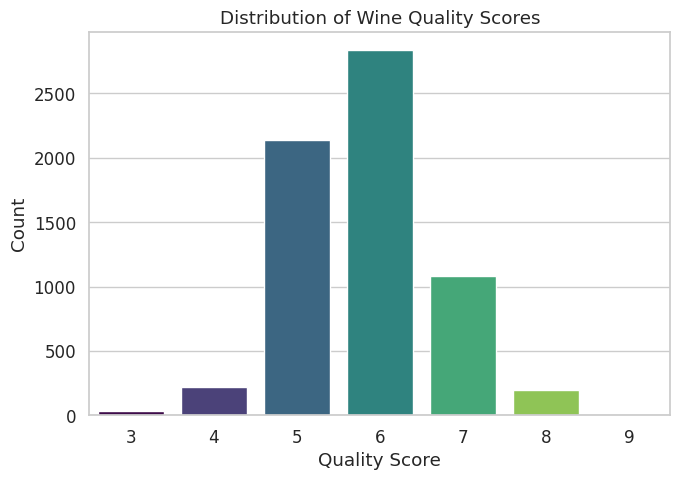

In [8]:
plt.figure(figsize=(7,5))
sns.countplot(x='quality', data=df, hue='quality', palette='viridis', legend=False)
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Interpretation:
- Most wines have quality scores of 5 or 6, indicating a concentration of moderate-quality wines.
- The dataset is somewhat balanced, but a slight concentration in the middle could impact model performance.

## 6. Correlation Analysis
Let's explore the relationships between the features and how they correlate with the target variable (`quality`). Correlation analysis can reveal which variables are most likely to influence wine quality.

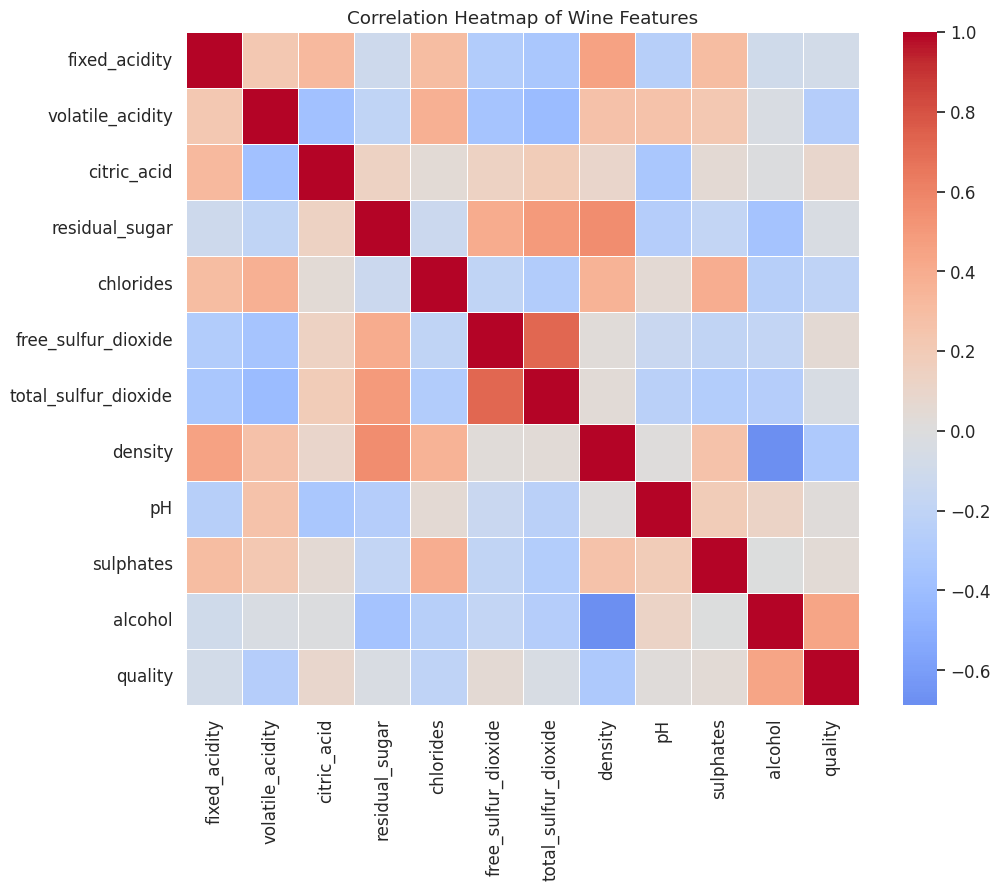

In [9]:
plt.figure(figsize=(11,9))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Wine Features')
plt.tight_layout()
plt.show()

### Key Findings from Correlation Analysis:
- **Alcohol** has the strongest positive correlation with `quality` (0.44), meaning higher alcohol content is associated with better wine quality.
- **Volatile acidity** has a strong negative correlation with `quality` (-0.39), meaning higher volatile acidity reduces wine quality.
- **Density** shows a moderate negative correlation with `alcohol` (-0.38) and `quality` (-0.29), suggesting denser wines are generally lower in alcohol content and quality.

## 7. Data Cleaning & Transformation
Some features, like `residual_sugar`, `free_sulfur_dioxide`, and `total_sulfur_dioxide`, are right-skewed. This can be problematic for certain models, as they tend to assume normal distributions. We'll apply log transformations to these features.

In [10]:
skewed_features = ['residual_sugar', 'free_sulfur_dioxide', 'total_sulfur_dioxide']
df_log = df.copy()

for col in skewed_features:
    df_log[col] = np.log1p(df_log[col])

df_log[skewed_features].describe().T

,count,mean,std,min,25%,50%,75%,max
residual_sugar,6497.0,1.620738,0.682150,0.470004,1.029619,1.386294,2.208274,4.201703
free_sulfur_dioxide,6497.0,3.267236,0.655486,0.693147,2.890372,3.401197,3.737670,5.669881
total_sulfur_dioxide,6497.0,4.578302,0.699104,1.945910,4.356709,4.779123,5.056246,6.089045


### Interpretation of Transformation:
Log transformation reduced the skewness in features like `residual_sugar` and `total_sulfur_dioxide`, making them more suitable for modeling.
These transformed variables now have a more normal distribution.

## 8. Feature Engineering
Feature engineering involves creating new variables that can enhance model performance. In this case, we create a binary target variable (`high_quality`) to distinguish high-quality wines (quality ≥ 7) from low-quality wines.

In [11]:
df_log['high_quality'] = (df_log['quality'] >= 7).astype(int)
df_log[['quality', 'high_quality']].head()

,quality,high_quality
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


Now, the dataset includes a `high_quality` binary feature that can be used for classification tasks.

## 9. Hypothesis Testing
Let's now test our hypotheses using statistical tests. We will examine the differences between high-quality and low-quality wines based on various features.

Hypotheses:
1. **H₁**: High-quality wines have higher alcohol content
2. **H₂**: High-quality wines have lower volatile acidity
3. **H₃**: High-quality wines have higher sulphates

### 9.1 Alcohol Content (Welch's t-test)

We hypothesized that high-quality wines would have higher alcohol content compared to low-quality wines. To test this, we performed Welch’s t-test for unequal variances between the alcohol content of high-quality wines (`quality >= 7`) and low-quality wines (`quality < 7`).

#### Null Hypothesis (H₀):
There is no difference in mean alcohol content between high-quality and low-quality wines.

#### Alternative Hypothesis (H₁):
High-quality wines have higher mean alcohol content than low-quality wines.

In [12]:
high_q = df_log[df_log['high_quality'] == 1]['alcohol']
low_q = df_log[df_log['high_quality'] == 0]['alcohol']

t_stat, p_value = stats.ttest_ind(high_q, low_q, equal_var=False)
t_stat, p_value

(np.float64(31.59846522158989), np.float64(1.785635605360441e-174))

#### Test Results:
- **t-statistic = 31.60**: This very large t-statistic suggests a substantial difference in alcohol content between the two groups.
- **p-value = 1.79e-174**: The extremely small p-value indicates that we can reject the null hypothesis at a significance level of 0.05.

#### Interpretation:
The results show that high-quality wines indeed have significantly higher alcohol content than low-quality wines. This strongly supports the hypothesis that alcohol content is a critical factor in determining wine quality.

### 9.2 Volatile Acidity (Welch's t-test)

We hypothesized that high-quality wines would have lower volatile acidity compared to low-quality wines. To test this, we performed a Welch’s t-test for unequal variances between the volatile acidity levels of high-quality wines (`quality >= 7`) and low-quality wines (`quality < 7`).

#### Null Hypothesis (H₀):
There is no difference in mean volatile acidity between high-quality and low-quality wines.

#### Alternative Hypothesis (H₁):
High-quality wines have lower volatile acidity than low-quality wines.

In [13]:
stats.ttest_ind(
    df_log[df_log['high_quality'] == 1]['volatile_acidity'],
    df_log[df_log['high_quality'] == 0]['volatile_acidity'],
    equal_var=False
)

TtestResult(statistic=np.float64(-15.5261688676099), pvalue=np.float64(3.290598744734189e-52), df=np.float64(2793.9430237753286))

#### Test Results:
- **t-statistic = -15.53**: A large negative t-statistic indicates that volatile acidity is much lower in high-quality wines compared to low-quality wines.
- **p-value = 3.29e-52**: The p-value is extremely small, far below 0.05, indicating that the difference is statistically significant.

#### Interpretation:
The results confirm that high-quality wines have significantly lower volatile acidity than low-quality wines. This suggests that volatile acidity is a strong predictor of wine quality, with lower levels associated with higher-quality wines.



### 9.3 Sulphates (Welch's t-test)

We hypothesized that high-quality wines would have higher sulphates than low-quality wines. To test this, we performed a Welch’s t-test for unequal variances between the sulphate levels of high-quality wines (`quality >= 7`) and low-quality wines (`quality < 7`).

#### Null Hypothesis (H₀):
There is no difference in mean sulphates between high-quality and low-quality wines.

#### Alternative Hypothesis (H₁):
High-quality wines have higher sulphates than low-quality wines.

In [14]:
stats.ttest_ind(
    df_log[df_log['high_quality'] == 1]['sulphates'],
    df_log[df_log['high_quality'] == 0]['sulphates'],
    equal_var=False
)

TtestResult(statistic=np.float64(2.5707140908485213), pvalue=np.float64(0.010227982950050016), df=np.float64(1814.8801144341933))

#### Test Results:
- **t-statistic = 2.57**: A positive t-statistic indicates that high-quality wines have higher sulphate content compared to low-quality wines.
- **p-value = 0.0102**: Since the p-value is smaller than 0.05, we can reject the null hypothesis and conclude that the difference in sulphates between high and low-quality wines is statistically significant.

#### Interpretation:
While the difference in sulphates is statistically significant, it is not as strong as the effect seen with alcohol content or volatile acidity. However, sulphates do play a role in determining wine quality, with higher sulphate levels being associated with higher-quality wines.



## Summary of Hypothesis Testing Results

1. **Alcohol Content**: High-quality wines have significantly higher alcohol content than low-quality wines (p < 0.05).
2. **Volatile Acidity**: High-quality wines have significantly lower volatile acidity than low-quality wines (p < 0.05).
3. **Sulphates**: High-quality wines have significantly higher sulphates than low-quality wines (p < 0.05), though this effect is weaker compared to alcohol and volatile acidity.

### Interpretation:
These findings support the idea that alcohol content and volatile acidity are the most important factors influencing wine quality. Sulphates also contribute to wine quality but appear to have a smaller effect compared to the other two features. These insights can be valuable for both winemakers and predictive modelers when developing models for wine quality classification.


## 10. Conclusion & Next Steps
### Conclusion:
- **Alcohol content**: Strong predictor for wine quality.
- **Volatile acidity**: Negatively impacts quality.
- **Feature engineering and transformations**: Improved analytical quality and model preparation.

### Next Steps:
- Build predictive classification models (e.g., Logistic Regression, Random Forest).
- Apply feature scaling for algorithms sensitive to feature magnitude.
- Evaluate model performance using metrics like ROC-AUC and F1-score.